# [VERSÃO 3] Módulos de Explicabilidade — Grad-CAM++, LIME e SHAP

Este notebook aplica três técnicas de explicabilidade — **Grad-CAM++**,
**LIME** e **SHAP** — ao modelo de classificação de tumores cerebrais
treinado no pipeline `[VERSAO_7]_Modelo_Desvio_Hiperparametro`, além de uma
avaliação quantitativa das explicações com os índices de **Gini** e
**AOPC**.

O notebook é organizado em **módulos independentes**, cada um com suas
próprias importações e configuração, de modo que seja possível rodar apenas
o módulo necessário (Grad-CAM++, LIME ou SHAP) sem depender dos outros.

O fluxo geral consiste em: baixar o dataset via `kagglehub`
(`mohammadhossein77/brain-tumors-dataset`), carregar automaticamente o
melhor modelo treinado (com base no F1 registrado em `execucoes.json`),
segmentar as imagens de entrada com o mesmo pipeline usado no treino (Otsu +
maior componente conectado + convex hull preenchido) e gerar as explicações
visuais e métricas para um banco de imagens de exemplo sorteado
automaticamente por classe.

## Estrutura do notebook
- **Módulo 0** — Configuração compartilhada (rodar sempre primeiro): mount do
  Drive, download do dataset, carregamento do melhor modelo, função de
  segmentação e montagem do banco de imagens de exemplo.
- **Módulo 1** — Grad-CAM++
- **Módulo 2** — LIME
- **Módulo 3** — SHAP
- **Módulo 4** — Avaliação Quantitativa (Índice de Gini e AOPC)

# Módulo 0 — Configuração Compartilhada

**Rode esta célula sempre que abrir o notebook ou reiniciar a sessão.**

In [ ]:
# --------------------------------------------------------------
# 0.1. Mount do Google Drive
# --------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# --------------------------------------------------------------
# 0.2. Importações gerais deste módulo
# --------------------------------------------------------------
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import kagglehub

# --------------------------------------------------------------
# 0.3. Caminhos do projeto
# --------------------------------------------------------------
BASE_DIR = '/content/drive/MyDrive/Projeto/Desv_Hip'
RUN_DIR = os.path.join(BASE_DIR, '224x224')
DADOS_DIR = os.path.join(RUN_DIR, 'resultados')
MODELOS_DIR = os.path.join(RUN_DIR, 'modelos_salvos')

# Pasta própria para os resultados de explicabilidade, organizada por técnica e por classe
EXPLICABILIDADE_DIR = os.path.join(RUN_DIR, 'explicabilidade')
os.makedirs(EXPLICABILIDADE_DIR, exist_ok=True)

IMAGE_SIZE = (224, 224)

# --------------------------------------------------------------
# 0.4. Download do dataset
# --------------------------------------------------------------
dataset_path = kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
print("Caminho do dataset:", dataset_path)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_paths_full = []
labels_raw_full = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths_full.append(os.path.join(root, file))
            labels_raw_full.append(os.path.basename(root))

# Nomes de classe descobertos dinamicamente (igual ao treino).
class_names_list = sorted(list(set(labels_raw_full)))
num_classes = len(class_names_list)
class_to_label = {name: i for i, name in enumerate(class_names_list)}
label_to_class = {i: name for name, i in class_to_label.items()}  # NOVO

print(f"\nClasses identificadas ({num_classes}): {class_names_list}")
for name, idx in class_to_label.items():
    count = labels_raw_full.count(name)
    print(f" - {idx}: {name} ({count} imagens)")

# --------------------------------------------------------------
# 0.5. Carregar o modelo com melhor F1 entre as seeds treinadas.
# --------------------------------------------------------------
RESULTS_PATH = os.path.join(DADOS_DIR, 'execucoes.json')

with open(RESULTS_PATH, 'r') as f:
    resultados = json.load(f)

melhor_execucao = max(resultados, key=lambda r: r['f1'])

modelo_path = melhor_execucao['modelo_path']
print(f"\nCarregando modelo da seed={melhor_execucao['seed']} "
      f"(F1={melhor_execucao['f1']:.4f}) de:\n{modelo_path}")

model = keras.models.load_model(modelo_path)
print("Modelo carregado com sucesso.")

# --------------------------------------------------------------
# 0.6. Função de segmentação
# --------------------------------------------------------------
def segment_image_cv(image_tensor):
    """
    Otsu (separa objeto do fundo por intensidade) + maior componente
    conectado (remove ruído solto) + convex hull preenchido (evita que um
    tumor com brilho parecido com o fundo vire um "buraco" na máscara).
    """
    img = image_tensor.numpy().astype(np.uint8) if hasattr(image_tensor, 'numpy') else image_tensor.astype(np.uint8)
    if len(img.shape) == 4:
        img = np.squeeze(img, axis=0)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    n_labels, labels_img, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    if n_labels > 1:  # label 0 é sempre o fundo
        maior_componente = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        thresh = np.where(labels_img == maior_componente, 255, 0).astype(np.uint8)

    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        maior_contorno = max(contornos, key=cv2.contourArea)
        hull = cv2.convexHull(maior_contorno)
        thresh_hull = np.zeros_like(thresh)
        cv2.drawContours(thresh_hull, [hull], -1, 255, thickness=cv2.FILLED)
        thresh = thresh_hull

    segmented = cv2.bitwise_and(img, img, mask=thresh)
    return segmented.astype(np.float32)


def carregar_e_segmentar(img_path):
    """Carrega uma imagem do disco, redimensiona para IMAGE_SIZE e segmenta.
    Retorna um array float32 com pixels 0-255, pronto para o modelo (sem
    normalização — ver célula 0.7)."""
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMAGE_SIZE)
    img_raw = tf.keras.preprocessing.image.img_to_array(img)
    return segment_image_cv(img_raw)


# --------------------------------------------------------------
# 0.7. Função de predição padrão (usada pelo LIME e pelo SHAP)
# --------------------------------------------------------------
def predict_fn(images):
    return model.predict(images, verbose=0)

# --------------------------------------------------------------
# 0.8. Banco de imagens de exemplo
# --------------------------------------------------------------
def montar_banco_imagens(n_por_classe=5, seed=42):
    rng = np.random.default_rng(seed)
    labels_raw_arr = np.array(labels_raw_full)
    banco = {}
    for classe in class_names_list:
        indices_classe = np.where(labels_raw_arr == classe)[0]
        n = min(n_por_classe, len(indices_classe))
        escolhidos = rng.choice(indices_classe, size=n, replace=False)
        banco[classe] = [image_paths_full[i] for i in escolhidos]
    return banco

banco_imagens = montar_banco_imagens(n_por_classe=5)

print("\nBanco de imagens de exemplo:")
for classe, imgs in banco_imagens.items():
    print(f" - {classe}: {len(imgs)} imagens")

print("\nMódulo 0 concluído — configuração compartilhada pronta.")


Mounted at /content/drive


100%|██████████| 221M/221M [00:01<00:00, 173MB/s]

Extracting files...


Caminho do dataset: /root/.cache/kagglehub/datasets/mohammadhossein77/brain-tumors-dataset/versions/3

Classes identificadas (4): ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
 - 0: Normal (3066 imagens)
 - 1: glioma_tumor (6307 imagens)
 - 2: meningioma_tumor (6391 imagens)
 - 3: pituitary_tumor (5908 imagens)

Carregando modelo da seed=2024 (F1=0.9903) de:
/content/drive/MyDrive/Projeto/Desv_Hip/224x224/modelos_salvos/Desv_Hip_224_seed2024.keras
Modelo carregado com sucesso.

Banco de imagens de exemplo:
 - Normal: 5 imagens
 - glioma_tumor: 5 imagens
 - meningioma_tumor: 5 imagens
 - pituitary_tumor: 5 imagens

Módulo 0 concluído — configuração compartilhada pronta.


In [ ]:
# --------------------------------------------------------------
# 0.9. Índice de Gini (concentração da explicação)
# --------------------------------------------------------------
def gini_index(importance_values):
    """Mede o quão concentrada (vs. espalhada) está a importância atribuída
    pela técnica de XAI. 0 = importância uniforme por toda a imagem,
    1 = toda a importância concentrada em poucos pixels/regiões."""
    valores = np.abs(np.asarray(importance_values, dtype=np.float64)).flatten()
    valores = np.sort(valores)
    n = len(valores)
    soma = valores.sum()
    if soma == 0 or n == 0:
        return 0.0
    cum = np.cumsum(valores)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)


# --------------------------------------------------------------
# 0.10. AOPC (Area Over the Perturbation Curve)
# --------------------------------------------------------------
def calcular_aopc(img_segmented, importance_map, target_class_idx,
                   n_segmentos=20, n_steps=10, valor_perturbacao=None):
    """
    Mede o quanto a probabilidade da classe alvo cai a medida que as
    regioes mais "importantes" (segundo a tecnica de XAI) vao sendo
    apagadas da imagem, uma a uma. Quanto MAIOR o AOPC, mais a tecnica
    esta apontando corretamente para regioes que o modelo realmente usa.

    - img_segmented: imagem (H, W, 3), 0-255, ja segmentada (saida de
      carregar_e_segmentar).
    - importance_map: mapa de importancia (H, W) ja redimensionado para o
      tamanho da imagem (heatmap do Grad-CAM++, |SHAP| por pixel, etc).
    - target_class_idx: indice da classe cuja probabilidade sera
      monitorada (normalmente a classe predita).
    - n_segmentos: em quantos blocos a imagem e dividida via SLIC para a
      perturbacao progressiva.
    - n_steps: quantos desses blocos (do mais importante ao menos
      importante) sao efetivamente removidos, um por um.
    """
    from skimage.segmentation import slic

    img = img_segmented.astype(np.float64)
    segments = slic(img.astype(np.uint8), n_segments=n_segmentos,
                     compactness=10, sigma=1, start_label=0)

    importancia_por_segmento = []
    for s in np.unique(segments):
        mask = segments == s
        importancia_por_segmento.append((s, importance_map[mask].mean()))
    importancia_por_segmento.sort(key=lambda x: x[1], reverse=True)

    n_steps = min(n_steps, len(importancia_por_segmento))
    valor_base = img.mean(axis=(0, 1)) if valor_perturbacao is None else valor_perturbacao

    img_perturbada = img.copy()
    prob_inicial = float(predict_fn(np.expand_dims(img, axis=0))[0, target_class_idx])

    quedas = []
    for k in range(n_steps):
        seg_id, _ = importancia_por_segmento[k]
        mask = segments == seg_id
        img_perturbada[mask] = valor_base
        prob_k = float(predict_fn(np.expand_dims(img_perturbada, axis=0))[0, target_class_idx])
        quedas.append(prob_inicial - prob_k)

    return float(np.mean(quedas)) if quedas else 0.0


# --------------------------------------------------------------
# 0.11. Arquivo de resultados acumulado (persiste no Drive entre sessoes,
#       entao funciona mesmo rodando os modulos em dias/sessoes diferentes)
# --------------------------------------------------------------
METRICAS_DIR = os.path.join(EXPLICABILIDADE_DIR, 'metricas')
os.makedirs(METRICAS_DIR, exist_ok=True)
METRICAS_PATH = os.path.join(METRICAS_DIR, 'resultados_metricas.json')

def carregar_metricas():
    if os.path.exists(METRICAS_PATH):
        with open(METRICAS_PATH, 'r') as f:
            return json.load(f)
    return []

def salvar_metrica(tecnica, classe, arquivo, gini, aopc, extra=None):
    registros = carregar_metricas()
    registro = {
        'tecnica': tecnica,
        'classe': classe,
        'arquivo': arquivo,
        'gini': gini,
        'aopc': aopc,
    }
    if extra:
        registro.update(extra)
    # substitui um registro existente da mesma (tecnica, classe, arquivo), se houver
    registros = [r for r in registros if not (
        r['tecnica'] == tecnica and r['classe'] == classe and r['arquivo'] == arquivo
    )]
    registros.append(registro)
    with open(METRICAS_PATH, 'w') as f:
        json.dump(registros, f, indent=2, ensure_ascii=False)
    return registro

print("Modulo 4.0 concluido - funcoes de Gini/AOPC e arquivo de metricas prontos.")
print(f"Resultados serao acumulados em: {METRICAS_PATH}")


Modulo 4.0 concluido - funcoes de Gini/AOPC e arquivo de metricas prontos.
Resultados serao acumulados em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/metricas/resultados_metricas.json


# Módulo 1 — Grad-CAM++

Requer o **Módulo 0** já executado nesta sessão. Gera mapas de calor
mostrando quais regiões da imagem mais influenciaram a predição do modelo.


### 1.1 Importações e preparação dos sub-modelos (rodar 1x por sessão)

In [ ]:
# --------------------------------------------------------------
# Importações específicas deste módulo
# --------------------------------------------------------------
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# --------------------------------------------------------------
# 1.1. Localizar a sub-rede EfficientNetB0 dentro do modelo treinado
#      Procura dinamicamente por qualquer camada cujo nome contenha
#      'efficientnet', mais robusto a mudanças de nomenclatura entre versões
#      do Keras/TensorFlow.
# --------------------------------------------------------------
inner_model = None
for layer in model.layers:
    if 'efficientnet' in layer.name.lower():
        inner_model = layer
        break

if inner_model is None:
    raise ValueError("Não foi possível localizar a EfficientNetB0 dentro do "
                      "modelo. Confira model.summary().")

print(f"Sub-rede encontrada: '{inner_model.name}'")

target_layer_name = 'top_activation'  # padrão do EfficientNet (última feature map antes do pooling)
target_layer = inner_model.get_layer(target_layer_name)
print(f"Camada alvo do Grad-CAM++: '{target_layer_name}' -> saída {target_layer.output.shape}")

# --------------------------------------------------------------
# 1.2. Criar o extrator de features (até a última conv) e o classificador
#      (o restante do modelo, após a EfficientNetB0)
# --------------------------------------------------------------
last_conv_model = tf.keras.Model(inputs=inner_model.input, outputs=target_layer.output)

classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
x = classifier_input
eff_layer_index = model.layers.index(inner_model)
for layer in model.layers[eff_layer_index + 1:]:
    x = layer(x)
classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

print(f"Extrator de Features: {last_conv_model.input.shape} -> {last_conv_model.output.shape}")
print(f"Classificador: {classifier_model.input.shape} -> {classifier_model.output.shape}")

# --------------------------------------------------------------
# 1.3. Função Grad-CAM++
# --------------------------------------------------------------
def gerar_gradcam_plus_plus(img_path):
    img_segmented = carregar_e_segmentar(img_path)
    img_batch = np.expand_dims(img_segmented, axis=0)

    with tf.GradientTape() as tape_1:
        with tf.GradientTape() as tape_2:
            with tf.GradientTape() as tape_3:
                conv_outputs = last_conv_model(img_batch)
                predictions = classifier_model(conv_outputs)
                best_class_index = tf.argmax(predictions[0])
                loss = predictions[:, best_class_index]
            first_grads = tape_3.gradient(loss, conv_outputs)
        second_grads = tape_2.gradient(first_grads, conv_outputs)
    third_grads = tape_1.gradient(second_grads, conv_outputs)

    global_sum = np.sum(conv_outputs, axis=(0, 1, 2))
    alpha_num = second_grads[0]
    alpha_denom = 2.0 * second_grads[0] + global_sum * third_grads[0]
    alpha_denom = np.where(alpha_denom != 0.0, alpha_denom, 1e-10)

    alphas = alpha_num / alpha_denom
    alphas_norm = np.sum(alphas, axis=(0, 1))
    alphas_norm = np.where(alphas_norm != 0.0, alphas_norm, 1e-10)
    alphas /= alphas_norm

    weights = np.maximum(first_grads[0], 0.0)
    deep_linearization_weights = np.sum(weights * alphas, axis=(0, 1))

    heatmap = np.sum(conv_outputs[0] * deep_linearization_weights, axis=-1)
    heatmap = np.maximum(heatmap, 0)  # ReLU
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)  # normaliza para 0-1

    return heatmap, img_segmented, int(best_class_index.numpy())

print("\nFerramentas do Grad-CAM++ prontas.")


Sub-rede encontrada: 'efficientnetb0'
Camada alvo do Grad-CAM++: 'top_activation' -> saída (None, 7, 7, 1280)
Extrator de Features: (None, 224, 224, 3) -> (None, 7, 7, 1280)
Classificador: (None, 7, 7, 1280) -> (None, 4)

Ferramentas do Grad-CAM++ prontas.


### 1.2 Execução do Grad-CAM++ por classe

* Mude `CLASSE_ALVO` para o nome da classe desejada (veja `class_names_list` no Módulo 0).

--- Processando Grad-CAM++ para: Normal ---
[1/5] Gerando para: N_207_HF_.jpg...


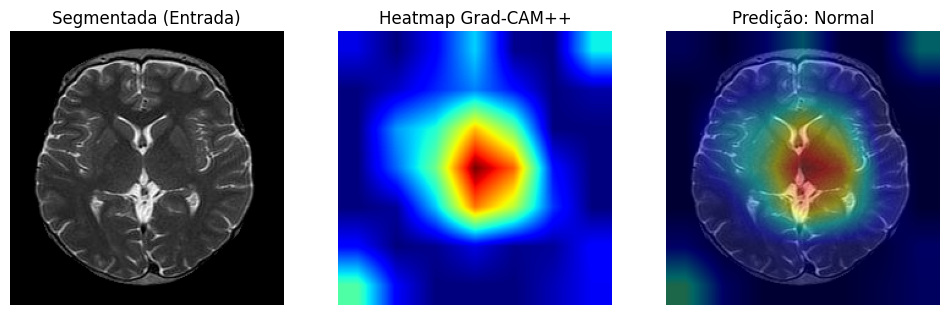

    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/GradCAM/Normal/GradCAM_N_207_HF_.jpg
[2/5] Gerando para: N_194_VF_.jpg...


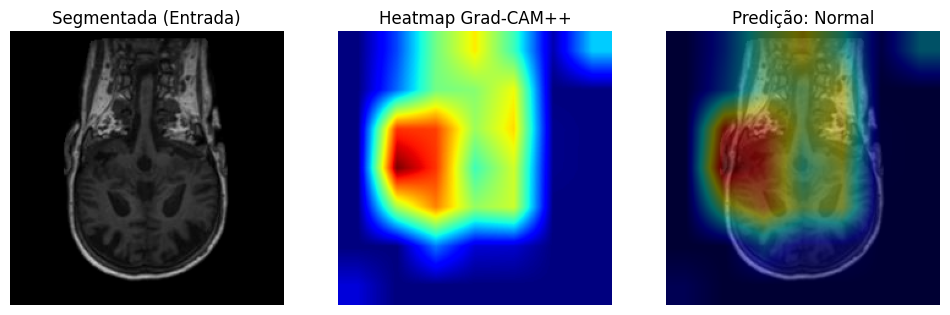

    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/GradCAM/Normal/GradCAM_N_194_VF_.jpg
[3/5] Gerando para: N_162_HF_.jpg...


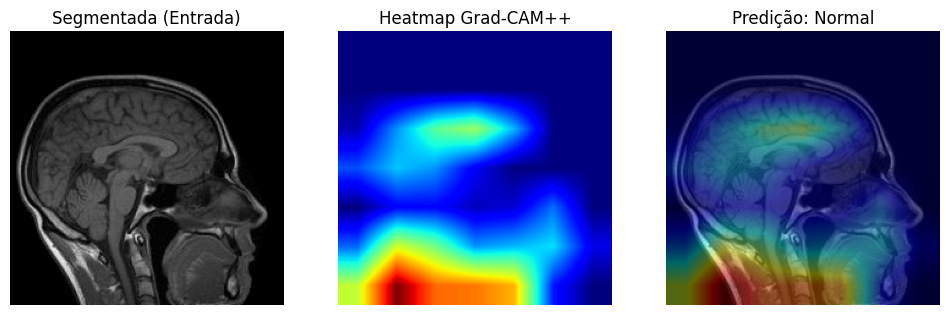

    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/GradCAM/Normal/GradCAM_N_162_HF_.jpg
[4/5] Gerando para: N_253_VF_.jpg...


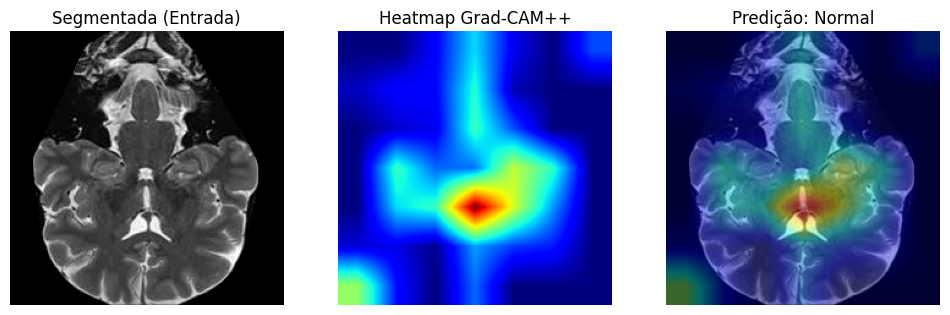

    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/GradCAM/Normal/GradCAM_N_253_VF_.jpg
[5/5] Gerando para: N_201_BR_.jpg...


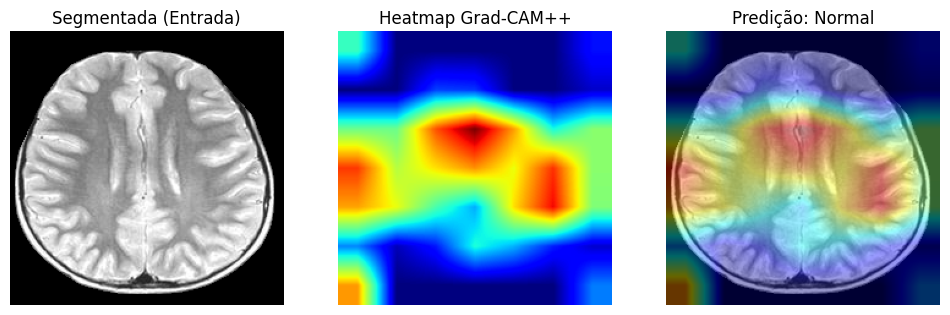

    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/GradCAM/Normal/GradCAM_N_201_BR_.jpg

Normal concluído.


In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[0]
# ==========================================

output_folder = os.path.join(EXPLICABILIDADE_DIR, 'GradCAM', CLASSE_ALVO)
os.makedirs(output_folder, exist_ok=True)

print(f"--- Processando Grad-CAM++ para: {CLASSE_ALVO} ---")

lista_imgs = banco_imagens[CLASSE_ALVO]

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"[{i+1}/{len(lista_imgs)}] Gerando para: {filename}...")

    try:
        heatmap, img_seg, pred_idx = gerar_gradcam_plus_plus(img_path)
        pred_classe = label_to_class[pred_idx]

        # --- VISUALIZAÇÃO ---
        heatmap_resized = cv2.resize(heatmap, IMAGE_SIZE)
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        img_seg_uint8 = img_seg.astype(np.uint8)
        superimposed = (img_seg_uint8 * 0.6 + heatmap_colored * 0.4).astype(np.uint8)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.title("Segmentada (Entrada)")
        plt.imshow(img_seg_uint8)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("Heatmap Grad-CAM++")
        plt.imshow(heatmap_resized, cmap='jet')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title(f"Predição: {pred_classe}")
        plt.imshow(superimposed)
        plt.axis('off')

        save_path = os.path.join(output_folder, f"GradCAM_{filename}")
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.show()
        plt.close()

        print(f"    -> Salvo em: {save_path}")

    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n{CLASSE_ALVO} concluído.")


### 1.3 Avaliação — Grad-CAM++


In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[3]

lista_imgs = banco_imagens[CLASSE_ALVO]
print(f"--- Avaliando Grad-CAM++ (Gini/AOPC) para: {CLASSE_ALVO} ---")

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"[{i+1}/{len(lista_imgs)}] {filename}...")
    try:
        heatmap, img_seg, pred_idx = gerar_gradcam_plus_plus(img_path)
        heatmap_resized = cv2.resize(heatmap, IMAGE_SIZE)

        gini = gini_index(heatmap_resized)
        aopc = calcular_aopc(img_seg, heatmap_resized, pred_idx)

        salvar_metrica('GradCAM++', CLASSE_ALVO, filename, gini, aopc,
                        extra={'classe_predita': label_to_class[pred_idx]})
        print(f"    -> Gini={gini:.4f} | AOPC={aopc:.4f}")
    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n{CLASSE_ALVO} (Grad-CAM++) avaliado. Resultados salvos em {METRICAS_PATH}")


--- Avaliando Grad-CAM++ (Gini/AOPC) para: pituitary_tumor ---
[1/5] P_438_SP_.jpg...
    -> Gini=0.5647 | AOPC=0.7361
[2/5] P_92.jpg...
    -> Gini=0.5745 | AOPC=0.8869
[3/5] P_204.jpg...
    -> Gini=0.4009 | AOPC=0.0005
[4/5] P_551_DA_.jpg...
    -> Gini=0.6141 | AOPC=0.3674
[5/5] P_532_RO_.jpg...
    -> Gini=0.5738 | AOPC=0.7881

pituitary_tumor (Grad-CAM++) avaliado. Resultados salvos em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/metricas/resultados_metricas.json


# Módulo 2 — LIME

Requer o **Módulo 0** já executado nesta sessão. Explica a predição
perturbando "superpixels" da imagem e vendo quais deles mais afetam a saída
do modelo.


### 2.1 Instalação e importações (rodar 1x por sessão)

In [ ]:
# --------------------------------------------------------------
# Importações específicas deste módulo
# --------------------------------------------------------------
!pip install --quiet lime

import os
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# --------------------------------------------------------------
# 2.1. Explicador do LIME
# --------------------------------------------------------------
explainer = lime_image.LimeImageExplainer()

print("LIME configurado.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
LIME configurado.


### 2.2 Execução do LIME por classe

* Mude `CLASSE_ALVO` para o nome da classe desejada (veja `class_names_list` no Módulo 0).
* `OPCAO_VISUAL`: `1` = Comparativo (lado a lado) | `2` = Prós/Contras (verde confirma, vermelho contradiz) | `3` = Isolamento (fundo preto, só as áreas mais importantes).
* O LIME é lento — espere ~40-60s por imagem.


--- Iniciando LIME (Opção 2) para pituitary_tumor ---
[1/5] Processando: P_438_SP_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

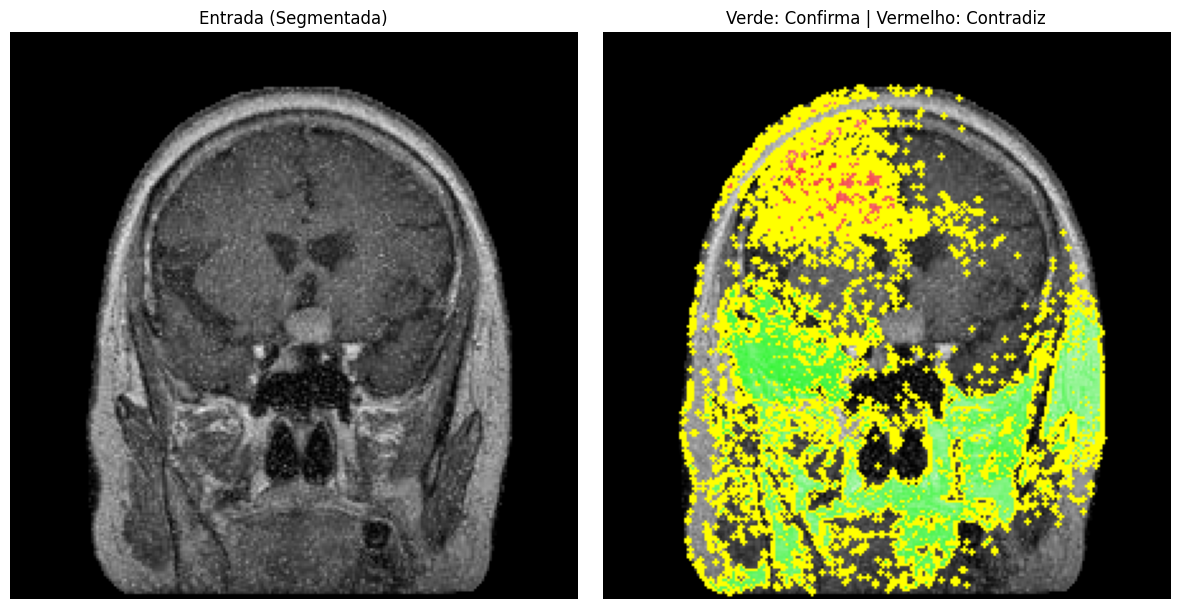

    -> Salvo: LIME_Op2_P_438_SP_.jpg
[2/5] Processando: P_92.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

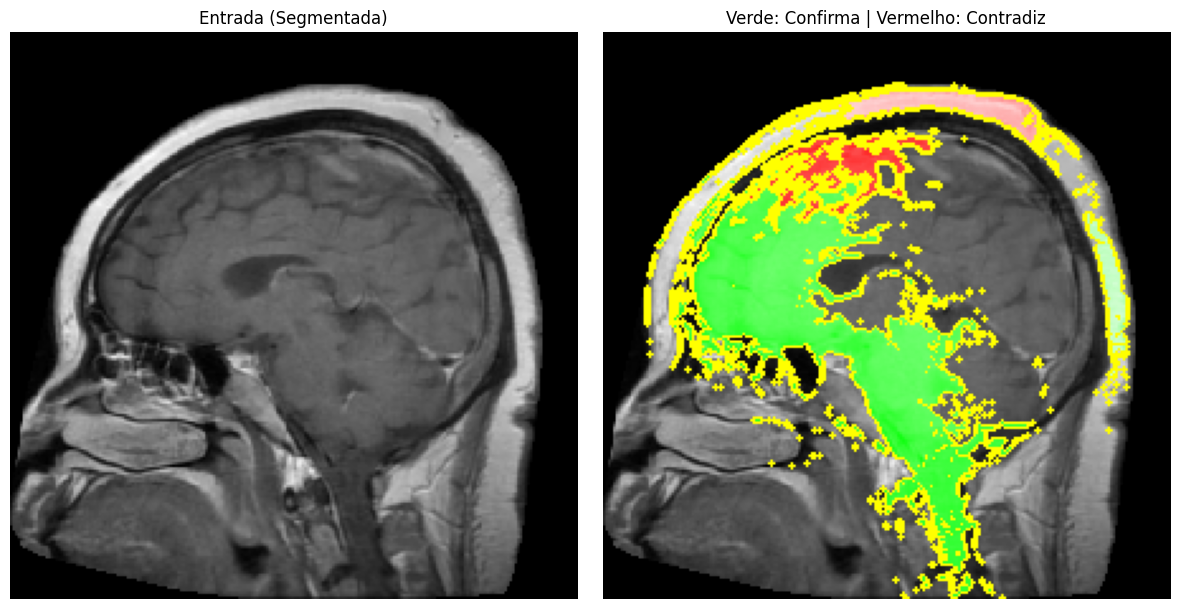

    -> Salvo: LIME_Op2_P_92.jpg
[3/5] Processando: P_204.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

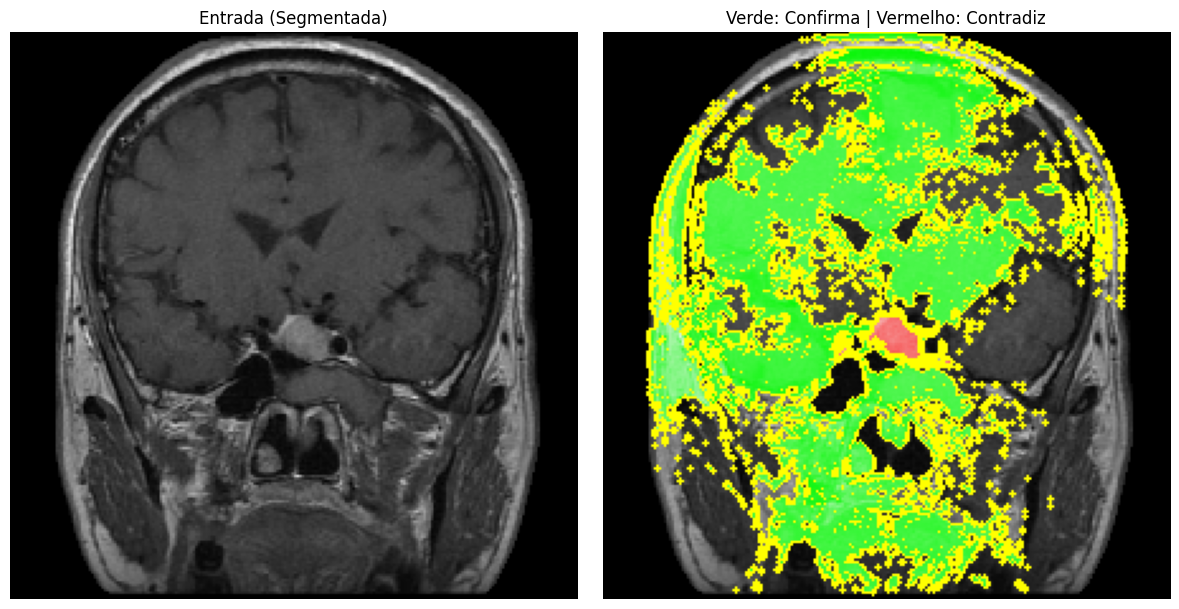

    -> Salvo: LIME_Op2_P_204.jpg
[4/5] Processando: P_551_DA_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

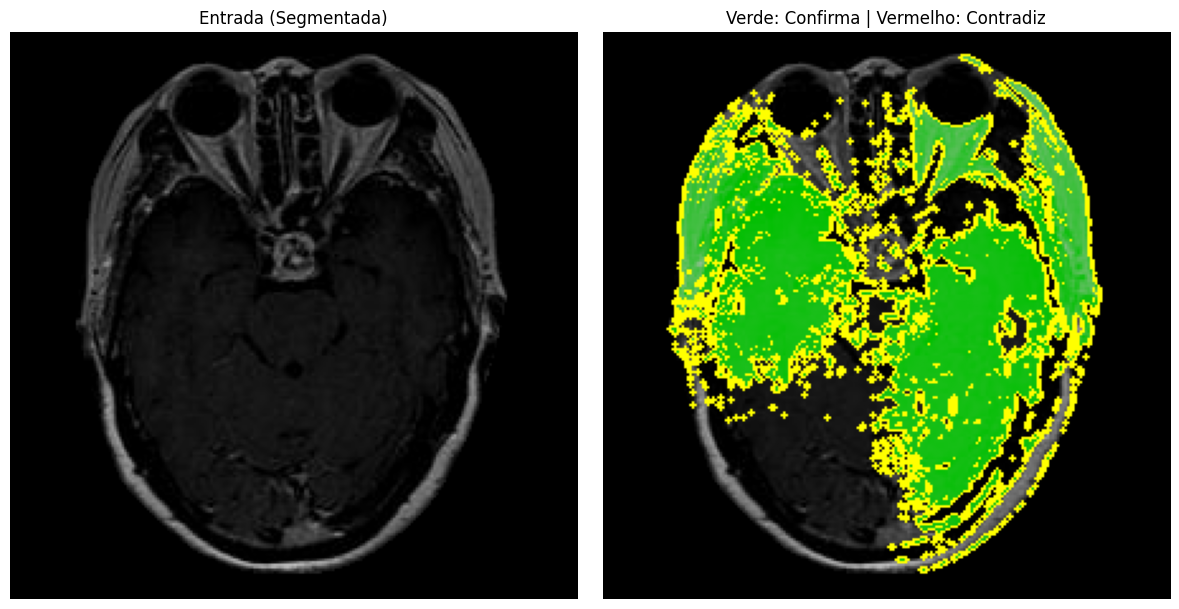

    -> Salvo: LIME_Op2_P_551_DA_.jpg
[5/5] Processando: P_532_RO_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

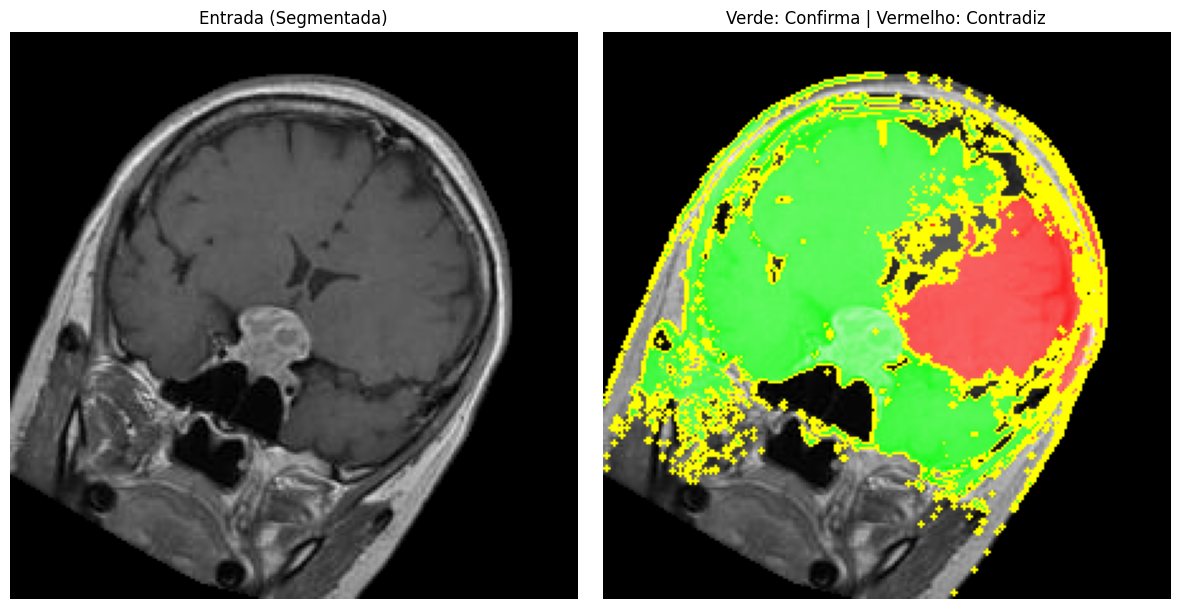

    -> Salvo: LIME_Op2_P_532_RO_.jpg

pituitary_tumor (Opção 2) concluído.


In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[3]
OPCAO_VISUAL = 2                   # 1 = Comparativo | 2 = Prós/Contras | 3 = Isolamento
# ==========================================

def rodar_lime_em_lote(nome_classe, opcao):
    if nome_classe not in banco_imagens:
        print(f"Erro: classe '{nome_classe}' não existe no banco_imagens.")
        return

    nome_opcao = f"Opcao_{opcao}"
    output_folder = os.path.join(EXPLICABILIDADE_DIR, 'LIME', nome_classe, nome_opcao)
    os.makedirs(output_folder, exist_ok=True)

    lista_imgs = banco_imagens[nome_classe]
    print(f"--- Iniciando LIME (Opção {opcao}) para {nome_classe} ---")

    for i, img_path in enumerate(lista_imgs):
        filename = os.path.basename(img_path)
        print(f"[{i+1}/{len(lista_imgs)}] Processando: {filename}...")

        try:
            img_segmented = carregar_e_segmentar(img_path)
            img_lime = img_segmented.astype('double')

            explanation = explainer.explain_instance(
                img_lime, predict_fn, top_labels=1, hide_color=0, num_samples=1000
            )
            top_class = explanation.top_labels[0]
            top_classe_nome = label_to_class[top_class]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

            ax1.imshow(img_segmented.astype('uint8'))
            ax1.set_title("Entrada (Segmentada)")
            ax1.axis('off')

            if opcao == 1:  # Comparativo (foco principal)
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=True, num_features=5, hide_rest=False
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title(f"LIME: Foco Principal ({top_classe_nome})")

            elif opcao == 2:  # Prós e contras
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=False, num_features=8, hide_rest=False
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title("Verde: Confirma | Vermelho: Contradiz")

            elif opcao == 3:  # Isolamento (fundo preto)
                temp, mask = explanation.get_image_and_mask(
                    top_class, positive_only=True, num_features=5, hide_rest=True
                )
                ax2.imshow(mark_boundaries(temp / 255.0, mask))
                ax2.set_title("Apenas Áreas Vitais (Isoladas)")

            else:
                print(f"    -> Opção inválida: {opcao}. Use 1, 2 ou 3.")
                plt.close()
                continue

            ax2.axis('off')

            nome_arquivo = f"LIME_Op{opcao}_{filename}"
            save_path = os.path.join(output_folder, nome_arquivo)

            plt.tight_layout()
            plt.savefig(save_path, bbox_inches='tight', dpi=150)
            plt.show()
            plt.close()

            print(f"    -> Salvo: {nome_arquivo}")

        except Exception as e:
            print(f"    -> Erro em {filename}: {e}")

    print(f"\n{nome_classe} (Opção {opcao}) concluído.")

# --- EXECUTAR ---
rodar_lime_em_lote(CLASSE_ALVO, OPCAO_VISUAL)


### 2.3 Avaliação — LIME

In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[3]

lista_imgs = banco_imagens[CLASSE_ALVO]
print(f"--- Avaliando LIME (Gini/AOPC) para: {CLASSE_ALVO} ---")

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"[{i+1}/{len(lista_imgs)}] {filename}...")
    try:
        img_segmented = carregar_e_segmentar(img_path)
        img_lime = img_segmented.astype('double')

        explanation = explainer.explain_instance(
            img_lime, predict_fn, top_labels=1, hide_color=0, num_samples=1000
        )
        top_class = explanation.top_labels[0]

        # Reconstroi um mapa de importancia pixel-a-pixel a partir dos pesos
        # do LIME por superpixel (mesmos segmentos usados pelo LIME).
        segments = explanation.segments
        pesos = dict(explanation.local_exp[top_class])
        importance_map = np.zeros(segments.shape, dtype=np.float64)
        for seg_id, peso in pesos.items():
            importance_map[segments == seg_id] = peso
        importance_map_abs = np.abs(importance_map)

        gini = gini_index(importance_map_abs)
        aopc = calcular_aopc(img_segmented, importance_map_abs, top_class)

        salvar_metrica('LIME', CLASSE_ALVO, filename, gini, aopc,
                        extra={'classe_predita': label_to_class[top_class]})
        print(f"    -> Gini={gini:.4f} | AOPC={aopc:.4f}")
    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n{CLASSE_ALVO} (LIME) avaliado. Resultados salvos em {METRICAS_PATH}")


--- Avaliando LIME (Gini/AOPC) para: pituitary_tumor ---
[1/5] P_438_SP_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Gini=0.4472 | AOPC=0.7449
[2/5] P_92.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Gini=0.5727 | AOPC=0.6443
[3/5] P_204.jpg...


...

    -> Gini=0.5505 | AOPC=0.5140
[4/5] P_551_DA_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Gini=0.5266 | AOPC=0.5118
[5/5] P_532_RO_.jpg...


  0%|          | 0/1000 [00:00<?, ?it/s]

    -> Gini=0.5940 | AOPC=0.6024

pituitary_tumor (LIME) avaliado. Resultados salvos em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/metricas/resultados_metricas.json


# Módulo 3 — SHAP

Requer o **Módulo 0** já executado nesta sessão. Usa a abordagem "black-box"
(`shap.Explainer` com `maskers.Image`) para atribuir, pixel a pixel, a
contribuição de cada região para cada classe.


### 3.1 Instalação e importações (rodar 1x por sessão)

In [ ]:
# --------------------------------------------------------------
# Importações específicas deste módulo
# --------------------------------------------------------------
!pip install --quiet shap

import os
import numpy as np
import shap
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 3.1. Dados de background (necessários para o SHAP "explicar" contra algo)
# --------------------------------------------------------------
background_images = []
for classe, caminhos in banco_imagens.items():
    for caminho in caminhos[:3]:  # 3 imagens por classe é suficiente para o background
        background_images.append(carregar_e_segmentar(caminho))

background_data = np.array(background_images)
print(f"Background data: {background_data.shape}")

# --------------------------------------------------------------
# 3.2. Configurar o explicador (black-box)
# --------------------------------------------------------------
masker = shap.maskers.Image(f"blur({IMAGE_SIZE[0]},{IMAGE_SIZE[1]})", (IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
explainer_shap = shap.Explainer(predict_fn, masker, output_names=class_names_list)

print("SHAP configurado.")


Background data: (12, 224, 224, 3)
SHAP configurado.


### 3.2 Execução do SHAP por classe

* Mude `CLASSE_ALVO` para o nome da classe desejada (veja `class_names_list` no Módulo 0).
* `max_evals=500` é um limite seguro. Para resultados mais detalhados, pode subir para 1000-2000 (mais lento).


In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[3]
MAX_EVALS = 500
# ==========================================

output_dir = os.path.join(EXPLICABILIDADE_DIR, 'SHAP', CLASSE_ALVO)
os.makedirs(output_dir, exist_ok=True)

print(f"Iniciando geração do SHAP para a classe: {CLASSE_ALVO}")

lista_imgs = banco_imagens[CLASSE_ALVO]

for i, caminho_teste in enumerate(lista_imgs):
    nome_arquivo = os.path.basename(caminho_teste)
    print(f"[{i+1}/{len(lista_imgs)}] Processando {nome_arquivo}...")

    try:
        img_seg_teste = carregar_e_segmentar(caminho_teste)
        img_teste_batch = np.expand_dims(img_seg_teste, axis=0)

        shap_values = explainer_shap(img_teste_batch, max_evals=MAX_EVALS, batch_size=50)

        shap.image_plot(shap_values, show=False)

        fig = plt.gcf()
        fig.set_size_inches(18, 5)

        caminho_salvar = os.path.join(output_dir, f"SHAP_{nome_arquivo}.png")
        plt.savefig(caminho_salvar, bbox_inches='tight', dpi=300)
        plt.close()

        print(f"    -> Salvo em: {caminho_salvar}")

    except Exception as e:
        print(f"    -> ERRO em {nome_arquivo}: {e}")

print(f"\n{CLASSE_ALVO} concluído.")


Iniciando geração do SHAP para a classe: pituitary_tumor
[1/5] Processando P_438_SP_.jpg...


    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/SHAP/pituitary_tumor/SHAP_P_438_SP_.jpg.png
[2/5] Processando P_92.jpg...


    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/SHAP/pituitary_tumor/SHAP_P_92.jpg.png
[3/5] Processando P_204.jpg...


    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/SHAP/pituitary_tumor/SHAP_P_204.jpg.png
[4/5] Processando P_551_DA_.jpg...


    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/SHAP/pituitary_tumor/SHAP_P_551_DA_.jpg.png
[5/5] Processando P_532_RO_.jpg...


    -> Salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/SHAP/pituitary_tumor/SHAP_P_532_RO_.jpg.png

pituitary_tumor concluído.


### 3.3 Avaliação — SHAP


In [ ]:
# ==========================================
# - 0: Normal
# - 1: glioma_tumor
# - 2: meningioma_tumor
# - 3: pituitary_tumor
# ==========================================
CLASSE_ALVO = class_names_list[3]
MAX_EVALS = 500

lista_imgs = banco_imagens[CLASSE_ALVO]
print(f"--- Avaliando SHAP (Gini/AOPC) para: {CLASSE_ALVO} ---")

for i, img_path in enumerate(lista_imgs):
    filename = os.path.basename(img_path)
    print(f"[{i+1}/{len(lista_imgs)}] {filename}...")
    try:
        img_seg = carregar_e_segmentar(img_path)
        img_batch = np.expand_dims(img_seg, axis=0)

        pred = predict_fn(img_batch)[0]
        target_idx = int(np.argmax(pred))

        shap_values = explainer_shap(img_batch, max_evals=MAX_EVALS, batch_size=50)
        # shap_values.values tem forma (1, H, W, 3, n_classes) -> pega a
        # classe predita e soma os 3 canais RGB para virar um mapa (H, W)
        sv = shap_values.values[0, ..., target_idx]
        importance_map = np.abs(sv).sum(axis=-1)

        gini = gini_index(importance_map)
        aopc = calcular_aopc(img_seg, importance_map, target_idx)

        salvar_metrica('SHAP', CLASSE_ALVO, filename, gini, aopc,
                        extra={'classe_predita': label_to_class[target_idx]})
        print(f"    -> Gini={gini:.4f} | AOPC={aopc:.4f}")
    except Exception as e:
        print(f"    -> ERRO em {filename}: {e}")

print(f"\n{CLASSE_ALVO} (SHAP) avaliado. Resultados salvos em {METRICAS_PATH}")


--- Avaliando SHAP (Gini/AOPC) para: pituitary_tumor ---
[1/5] P_438_SP_.jpg...


  0%|          | 0/498 [00:00<?, ?it/s]

    -> Gini=0.4391 | AOPC=0.8889
[2/5] P_92.jpg...
    -> Gini=0.4141 | AOPC=0.9312
[3/5] P_204.jpg...
    -> Gini=0.5065 | AOPC=0.3401
[4/5] P_551_DA_.jpg...
    -> Gini=0.5712 | AOPC=0.3371
[5/5] P_532_RO_.jpg...
    -> Gini=0.5279 | AOPC=0.7368

pituitary_tumor (SHAP) avaliado. Resultados salvos em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/metricas/resultados_metricas.json


# Módulo 4 — Avaliação Quantitativa (Índice de Gini e AOPC)

Requer o **Módulo 0** já executado nesta sessão. Calcula duas métricas para
cada técnica de XAI (Grad-CAM++, LIME, SHAP):

- **Índice de Gini**: mede o quão *concentrada* está a importância atribuída
  pela explicação. Vai de 0 (importância espalhada por toda a imagem) a 1
  (importância concentrada em pouquíssimos pixels/regiões).
- **AOPC (Area Over the Perturbation Curve)**: mede o quanto a probabilidade
  da classe predita cai quando as regiões apontadas como mais importantes
  vão sendo apagadas, uma a uma. Quanto **maior** o AOPC, mais a explicação
  está de fato apontando para regiões que o modelo usa na decisão.

**Como isso funciona "por partes":** os resultados de cada técnica são
salvos, incrementalmente, num arquivo JSON dentro do Drive
(`explicabilidade/metricas/resultados_metricas.json`). Isso significa que
você pode rodar a avaliação do Grad-CAM++ hoje, a do LIME depois, a do SHAP
em outro dia — os resultados vão se acumulando nesse arquivo. O relatório
final pode ser rodado a qualquer momento e sempre mostra tudo
o que já foi calculado até ali, mesmo que incompleto.

### 4.1 Relatório consolidado

Pode ser rodado a qualquer momento — só precisa do **Módulo 0** nesta sessão. Mostra tudo o que já foi calculado até este
ponto, mesmo que ainda faltem técnicas ou classes.

In [ ]:
import pandas as pd

registros = carregar_metricas()
if not registros:
    print("Nenhuma metrica calculada ainda. Rode os modulos 4.1/4.2/4.3 primeiro.")
else:
    df = pd.DataFrame(registros)
    print(f"Total de avaliacoes registradas: {len(df)}\n")

    resumo = df.groupby('tecnica')[['gini', 'aopc']].agg(['mean', 'std', 'count'])
    print("=== Resumo por tecnica (todas as classes ja avaliadas) ===")
    display(resumo)

    resumo_classe = df.groupby(['tecnica', 'classe'])[['gini', 'aopc']].mean()
    print("\n=== Detalhe por tecnica x classe ===")
    display(resumo_classe)

    csv_path = os.path.join(METRICAS_DIR, 'resumo_metricas.csv')
    df.to_csv(csv_path, index=False)
    print(f"\nCSV completo salvo em: {csv_path}")


Total de avaliacoes registradas: 60

=== Resumo por tecnica (todas as classes ja avaliadas) ===


gini                      aopc                
               mean       std count      mean       std count
tecnica                                                      
GradCAM++  0.631998  0.113745    20  0.528847  0.323235    20
LIME       0.563926  0.065751    20  0.547382  0.215467    20
SHAP       0.494721  0.099139    20  0.522266  0.299662    20


=== Detalhe por tecnica x classe ===


gini      aopc
tecnica   classe                              
GradCAM++ Normal            0.550455  0.133788
          glioma_tumor      0.694073  0.581904
          meningioma_tumor  0.737864  0.843864
          pituitary_tumor   0.545600  0.555831
LIME      Normal            0.512207  0.280951
          glioma_tumor      0.570215  0.536846
          meningioma_tumor  0.635091  0.768235
          pituitary_tumor   0.538191  0.603495
SHAP      Normal            0.411155  0.197264
          glioma_tumor      0.476062  0.507687
          meningioma_tumor  0.599902  0.737313
          pituitary_tumor   0.491764  0.646800


CSV completo salvo em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/explicabilidade/metricas/resumo_metricas.csv
